# Project 1 - 158755

#### Student name: S M Amit Hasan
#### Student ID: 25004146


# Introduction

In recent years, broadband connectivity has played a crucial role in shaping digital access and online engagement in New Zealand. This project explores broadband connectivity trends using datasets from Stats NZ to analyze broadband data usage patterns and the evolution of broadband technologies over time. By conducting exploratory data analysis (EDA), we aim to uncover key trends, correlations, and insights that illustrate how internet usage has changed. This analysis focuses on understanding how broadband data allowance distribution has evolved, examining the adoption trends of different broadband technologies, and determining whether there has been a noticeable shift toward any newer technology or usage pattern.

#### Datasets used:
1. Maximum broadband data allowances (Annual-Jun)
2. Active broadband connection technology types (Annual-Jun)

#### Dataset sources: 
1. https://infoshare.stats.govt.nz/SelectVariables.aspx?pxID=a322f55a-38d4-4db0-b0cb-3dc3a35a9020
2. https://infoshare.stats.govt.nz/SelectVariables.aspx?pxID=d86993b8-58f7-4fc6-88c3-1bb9a5fa4c73
   
### Research Questions

1. How has broadband data allowance distribution changed over time?
2. What trends can be observed in the adoption of broadband technology types?
3. Is there a shift towards unlimited data broadband plans?
4. How has fibre optic adoption changed compared to other broadband types?


### Executive Summary

This analysis examines broadband connectivity in New Zealand, focusing on data caps and technology adoption trends. Findings highlight increasing adoption of unlimited data plans and a transition from older technologies like DSL to fibre optic. These insights provide valuable context for policymakers and internet service providers.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Wrangling 

In [6]:
broadband_data = pd.read_csv("broadband_allowances.csv")
technology_data = pd.read_csv("broadband_technology.csv")

In [8]:
broadband_data.head(), technology_data.head()

(   Year  Less than 5GB  5GB to less than 20GB  20GB to less than 50GB  \
 0  2011         131000                 117000                  483000   
 1  2012         181000                 227000                  623000   
 2  2013         230000                 116000                  580000   
 3  2014         147000                  76000                  548000   
 4  2015         119000                  49000                  448000   
 
    50GB or more  50GB to less than 100GB  100GB or more  Total with data cap  \
 0        131400                    66000          76000              1176000   
 1        251400                   136000         116000              1282000   
 2        433000                   265000         169000              1360000   
 3        633000                   436000         197000              1402000   
 4        465000                   398000          66000              1080000   
 
    No data cap (eg flat rate)  Total broadband connections  
 0  

In [10]:
broadband_data.isnull().sum()

Year                           0
Less than 5GB                  0
5GB to less than 20GB          0
20GB to less than 50GB         0
50GB or more                   0
50GB to less than 100GB        0
100GB or more                  0
Total with data cap            0
No data cap (eg flat rate)     0
Total broadband connections    0
dtype: int64

In [12]:
technology_data.isnull().sum()

Year                                              0
Digital subscriber line                           0
Cellular, satellite, cable, and fixed wireless    0
Fibre optic                                       0
Total broadband connections                       0
dtype: int64

In [14]:
broadband_data = broadband_data.dropna(axis=1, how="all")
technology_data = technology_data.dropna(axis=1, how="all")

In [16]:
merged_year = pd.merge(broadband_data, technology_data, on=["Year"], how="inner")

# EDA/Data Visulisation


In [19]:
broadband_data.describe()

,Year,Less than 5GB,5GB to less than 20GB,20GB to less than 50GB,50GB or more,50GB to less than 100GB,100GB or more,Total with data cap,No data cap (eg flat rate),Total broadband connections
count,8.00000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000e+00,8.000000e+00,8.000000e+00
mean,2014.50000,113300.000000,79112.500000,382750.000000,391225.000000,262500.000000,129875.000000,1.005250e+06,4.508750e+05,1.449000e+06
std,2.44949,76669.830162,73474.688304,231311.015117,151086.028001,123692.013832,56047.014703,3.742492e+05,4.183367e+05,1.296897e+05
min,2011.00000,1400.000000,4900.000000,30000.000000,131400.000000,66000.000000,63000.000000,4.330000e+05,6.800000e+04,1.184000e+06
25%,2012.75000,56750.000000,24250.000000,231500.000000,327600.000000,195250.000000,73500.000000,6.937500e+05,7.450000e+04,1.413500e+06
50%,2014.50000,125000.000000,62500.000000,465500.000000,415000.000000,277000.000000,142500.000000,1.128000e+06,3.270000e+05,1.486000e+06
75%,2016.25000,155500.000000,116250.000000,556000.000000,465250.000000,320750.000000,173500.000000,1.301500e+06,8.037500e+05,1.513250e+06
max,2018.00000,230000.000000,227000.000000,623000.000000,633000.000000,436000.000000,197000.000000,1.402000e+06,1.072000e+06,1.609000e+06


In [21]:
technology_data.describe()

,Year,Digital subscriber line,"Cellular, satellite, cable, and fixed wireless",Fibre optic,Total broadband connections
count,8.00000,8.000000e+00,8.00000,8.000000,8.000000e+00
mean,2014.50000,1.128125e+06,477875.00000,174762.500000,1.780625e+06
std,2.44949,1.728570e+05,56599.94321,218627.667426,1.661917e+05
min,2011.00000,8.290000e+05,413000.00000,3700.000000,1.450000e+06
25%,2012.75000,1.021000e+06,437000.00000,11100.000000,1.733000e+06
50%,2014.50000,1.160000e+06,469500.00000,75500.000000,1.849000e+06
75%,2016.25000,1.233250e+06,501250.00000,275750.000000,1.879250e+06
max,2018.00000,1.335000e+06,570000.00000,598000.000000,1.926000e+06


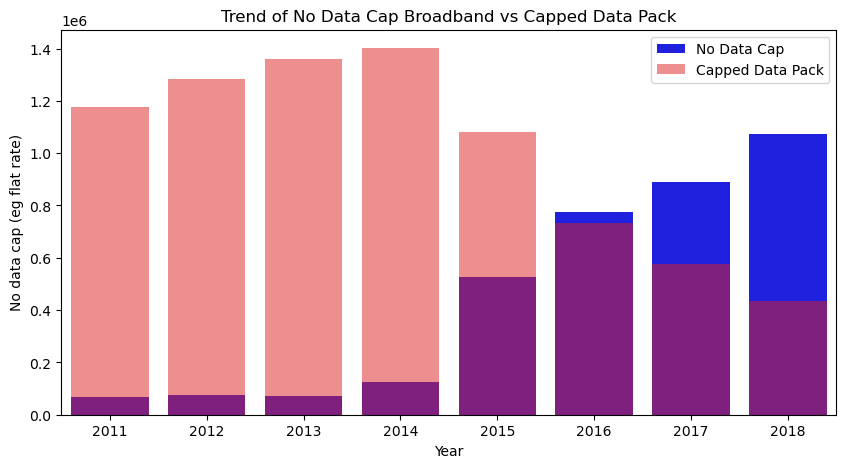

In [23]:
plt.figure(figsize=(10, 5))
sns.barplot(data=broadband_data, x="Year", y="No data cap (eg flat rate)", color="blue", label="No Data Cap")
sns.barplot(data=broadband_data, x="Year", y="Total with data cap", color="red", alpha=0.5, label="Capped Data Pack")
plt.legend()
plt.title("Trend of No Data Cap Broadband vs Capped Data Pack")
plt.show()

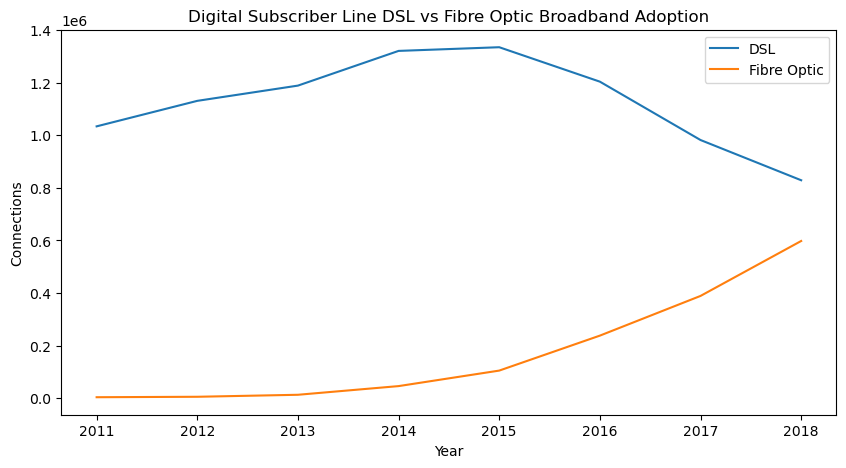

In [25]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=technology_data, x='Year', y='Digital subscriber line', label='DSL')
sns.lineplot(data=technology_data, x='Year', y='Fibre optic', label='Fibre Optic')
plt.xlabel('Year')
plt.ylabel('Connections')
plt.title('Digital Subscriber Line DSL vs Fibre Optic Broadband Adoption')
plt.legend()
plt.show()

# Analysis 

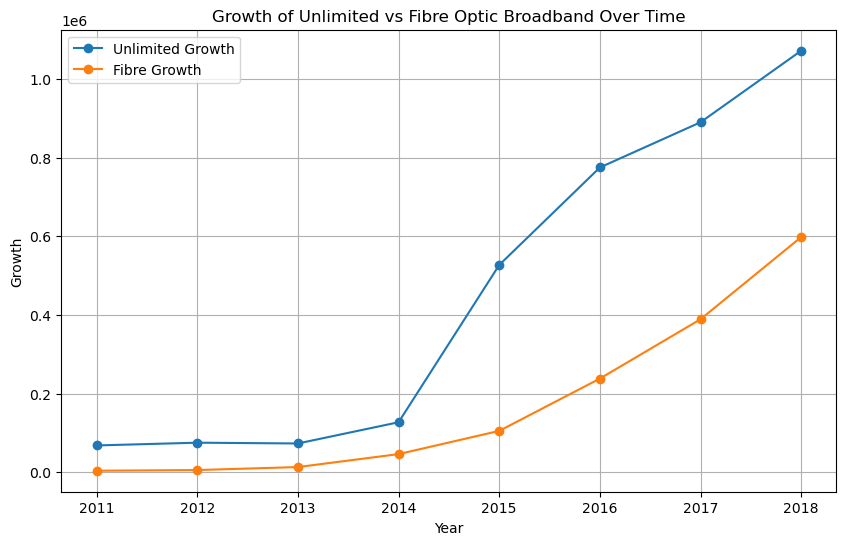

In [28]:
unlimited_growth = broadband_data[['Year', 'No data cap (eg flat rate)']]
fibre_growth = technology_data[['Year', 'Fibre optic']]
merged_data = pd.merge(unlimited_growth, fibre_growth, on='Year', how='inner')

plt.figure(figsize=(10, 6))
plt.plot(merged_data['Year'], merged_data['No data cap (eg flat rate)'], label='Unlimited Growth', marker='o')
plt.plot(merged_data['Year'], merged_data['Fibre optic'], label='Fibre Growth', marker='o')

plt.xlabel('Year')
plt.ylabel('Growth')
plt.title('Growth of Unlimited Data Plan vs Fibre Optic Broadband Over Time')
plt.legend()

plt.grid(True)
plt.show()

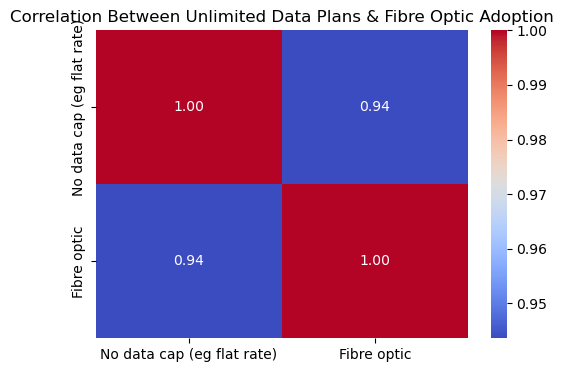

In [32]:
correlation_matrix = merged_data[['No data cap (eg flat rate)', 'Fibre optic']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Unlimited Data Plans & Fibre Optic Adoption")
plt.show()

# Conclusion 

The analysis highlights a significant transformation in broadband usage patterns in New Zealand. Over the years, there has been a marked increase in the adoption of unlimited data broadband plans, suggesting a growing demand for high-speed internet and data-intensive services such as streaming, remote work, and online education. This shift indicates that consumers are moving away from capped data plans in favor of more flexible and high-capacity broadband options. Additionally, the adoption of fibre optic broadband has grown substantially, gradually replacing older DSL technology. This transition reflects a broader nationwide infrastructure upgrade.

### Key findings:

1. The number of broadband users with no data cap has consistently increased.
2. Fibre optic broadband has experienced rapid adoption, surpassing older technologies.
3. DSL connections have steadily declined, suggesting a shift in consumer preference.
4. Internet infrastructure improvements have led to greater connectivity options.

# Bibliography (optional) 

1. Maximum broadband data allowances by connection type (Annual-Jun) from https://infoshare.stats.govt.nz/SelectVariables.aspx?pxID=a322f55a-38d4-4db0-b0cb-3dc3a35a9020
2. Active broadband connection technology types (Annual-Jun) from https://infoshare.stats.govt.nz/SelectVariables.aspx?pxID=d86993b8-58f7-4fc6-88c3-1bb9a5fa4c73